Binary vocalization classification using marmoset ECoG recordings.

- Extract pre-vocalization and baseline neural activity
- Train a 1D ResNet model for vocalization classification



In [7]:
import os
from scipy.io import loadmat
import h5py
import numpy as np
import shutil
import matplotlib.pyplot as plt
from copy import deepcopy
from sklearn.utils import resample
from sklearn.model_selection import train_test_split

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import pickle

In [9]:
def load_dataset (folder_path):
    files = []
    for f in os.listdir(folder_path):
        if f.endswith('.mat'):
            f_path = os.path.join(folder_path, f)

            try:
                files.append(f_path)
                print('cool')
            except Exception as e:
                print(f"Error loading {f}: {e}")

    return files

In [10]:
def load_dataset_train_test(data_pipe_folder):

    train_files = []
    test_files = []
 
    for folder in os.listdir(data_pipe_folder):
        folder_lower = folder.lower()
        folder_path_full = os.path.join(data_pipe_folder, folder)
    
        if os.path.isdir(folder_path_full):
            if 'train' in folder_lower:
                train_files.extend(load_dataset(folder_path_full))
    
            elif 'test' in folder_lower:
                test_files.extend(load_dataset(folder_path_full))
    
    return train_files, test_files
            

In [ ]:
def load_monkey_ecog_data(filepath):


    with h5py.File(filepath, 'r') as f:
    
        ecog_struct = f['ECoGMX']
        
        #neural_data = np.array(ecog_struct['neural_delta2'])
        print(filepath)
        #neural_data = np.array(ecog_struct['neural_hgamma'])
        neural_data = np.array(ecog_struct['neural_raw'])
        monkey = np.array(ecog_struct['voc_ch']).flatten()

        voc_dur = np.array(ecog_struct['voc_dur']).squeeze()
        voc_dur = np.atleast_1d(voc_dur)
        
        pre = 4000

        vocal_start = np.full(len(monkey), pre)

        vocal_stop = vocal_start + voc_dur 
        
        ntrials, nchannels, ntimepoints = neural_data.shape
        
        print(neural_data.shape)
        

    return neural_data, monkey, vocal_start, vocal_stop, voc_dur   

In [12]:
def get_data(mat_files):

    all_data = []
    
    for mat_file in mat_files:
    
        if 'Baseline' in mat_file:
        
            neural_data, monkey, vocal_start, vocal_stop, voc_dur = load_monkey_ecog_data(mat_file)
            print(neural_data.shape)
            print(f"[Baseline file] {mat_file}, shape: {neural_data.shape}")
        
        
            one_data = {
                    'neural_data': neural_data,
                    'file': mat_file,
                    'monkey': monkey
                }
            all_data.append(one_data)
        
        else:
            neural_data, monkey, vocal_start, vocal_stop, voc_dur = load_monkey_ecog_data(mat_file)
            print(f"[Vocalization file] {mat_file}, shape: {neural_data.shape}")
        
            monkey_selec = np.where(monkey == 1)[0]
            print( monkey_selec)
        
    
            if len(monkey_selec) > 0:
        
                one_data = {
                    'neural_data': neural_data[monkey_selec, :, :],
                    'vocal_start': vocal_start[monkey_selec],
                    'vocal_stop': vocal_start[monkey_selec],
                    'voc_dur': voc_dur[monkey_selec],
                    'file': mat_file,
                    'monkey': monkey[monkey_selec]
                }
                all_data.append(one_data)
    
    print(f"Total files: {len(mat_files)}, files with monkey==1 trials: {len(all_data)}")
    print(f"Total selected trials: {sum([d['neural_data'].shape[0] for d in all_data])}")

    return all_data

In [13]:
def get_ECoG_inmemory(all_data):

    all_neural_data = []
    
    for d in all_data:
        neural_data = d['neural_data']
        all_neural_data.append(neural_data)
    
    try:
        all_neural_data = np.concatenate(all_neural_data, axis=0)  # trial 维度拼接
        print(f"All neural_data shape: {all_neural_data.shape}")
    except ValueError as e:
        print("Error during concatenation:", e)

    return all_neural_data

In [ ]:
def get_balanced_data(all_data, all_neural_pre_voc, baseline_trials, vocal_trials, trial_idx):

    labels = []
    baseline_data = []
    vocal_data = []


    
    for d in all_data: 
        n_trials = d['neural_data'].shape[0]
        print(f"ntrials: {n_trials}")
    
        pre_voc_segment = all_neural_pre_voc[trial_idx : trial_idx + n_trials]
        
        if 'Baseline' in d['file']:
            baseline_trials += n_trials
            labels.extend([0] * n_trials)
            baseline_data.append(pre_voc_segment)
        else:
            vocal_trials += n_trials
            labels.extend([1] * n_trials)
            vocal_data.append(pre_voc_segment)
    
        print(f"Total baseline trials: {baseline_trials}")
        print(f"Total vocalization trials: {vocal_trials}")
        trial_idx += n_trials
        print(f"trial_idx: {trial_idx}")
    
    labels = np.array(labels)
    print(f"Labels shape: {labels.shape}")
    print(f"Example label distribution:{np.bincount(labels)}")
    
    baseline_data = np.concatenate(baseline_data, axis=0)
    vocal_data = np.concatenate(vocal_data, axis=0)
    
    print("After slicing and concatenation:")
    print("baseline_data shape:", baseline_data.shape)
    print("vocal_data shape:", vocal_data.shape)
    
    
    n_vocal = vocal_data.shape[0]
    
    baseline_bootstrap = resample(
        baseline_data,
        replace = True,
        n_samples = n_vocal,
        random_state = 79   
    )
    
    x_balanced = np.concatenate([baseline_bootstrap, vocal_data], axis=0) 
    y_balanced = np.array(
        [0] * n_vocal + 
        [1] * n_vocal
    )   

    y_balanced = tf.keras.utils.to_categorical(y_balanced, num_classes=2)  
    
    print(f"Balanced X shape: {x_balanced.shape}")
    print(f"Balanced y shape: {y_balanced.shape}")
    #print(f"Label distribution: {np.bincount(y_balanced)}")

    return x_balanced, y_balanced


In [ ]:
def get_paramater_(X_train, X_val):
    
    n_trials_train, n_channels_train, n_times_train = X_train.shape
      
    # z-score 
    mean_train = np.mean(X_train, axis=(0,2), keepdims=True)
    std_train = np.std(X_train, axis=(0,2), keepdims=True)

    
    X_train_norm = (X_train - mean_train) / (std_train + 1e-6)
    print(f"X_ shape:{X_train_norm.shape}")


    X_val_norm = (X_val - mean_train) / (std_train + 1e-6)
    print(f"X_val_ shape: {X_val_norm.shape}") 


    return n_trials_train, n_channels_train, n_times_train, mean_train, std_train, X_train_norm, X_val_norm

In [ ]:
data_pipe_folder = '...\DATA\DATA_VOCAL\DATA_PIPE\c'

train_files, test_files = load_dataset_train_test(data_pipe_folder)

pre_voc_t = 4000
pre_voc_before_t = 500



In [ ]:


baseline_trials = 0
vocal_trials = 0
trial_idx = 0
#gsbfvdcax Fa
all_data_train =  get_data(train_files)
all_neural_data_train = get_ECoG_inmemory(all_data_train)


all_neural_pre_voc_train = deepcopy(all_neural_data_train[:,:,(pre_voc_t-pre_voc_before_t):pre_voc_t])



x_balanced_train, y_balanced_train = get_balanced_data(all_data_train, all_neural_pre_voc_train, baseline_trials, vocal_trials, trial_idx)

In [ ]:

# 80% train, 20% val 
X_train, X_val, y_train, y_val = train_test_split(
    x_balanced_train, 
    y_balanced_train, 
    test_size = 0.2, 
    random_state = 79, 
    stratify = y_balanced_train
    )
    
n_trials_train, n_channels_train, n_times_train, mean_train, std_train, X_train_norm, X_val_norm = get_paramater_(X_train, X_val)



X_ shape:(278, 96, 500)
X_val_ shape: (70, 96, 500)


In [22]:
import sys

sys.path.append(r'J:\Codes_Res')  

from ResNet_1DCNN import ResNet

In [ ]:
# Model Construct

length = 500#n_times_train  

#input_shape=(None, length, num_channel))

model_name = 'ResNet18'
model_width = 32  
num_channel = 96
problem_type = 'Classification'  
output_nums = 2  


model = ResNet(
    length, 
    num_channel, 
    num_filters = model_width, 
    problem_type = problem_type, 
    output_nums = output_nums, 
    pooling = 'avg', 
    dropout_rate = 0.5).ResNet18()   # dropout_rate=0.5



model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate = 1e-3),   # why learning_rate=0.0003
             # loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), #loss=tf.keras.losses.MeanAbsoluteError(), 
              loss = tf.keras.losses.CategoricalCrossentropy(from_logits = False),  #CategoricalCrossentropy 和 SparseCategoricalCrossentropy的区别
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 500, 96)           │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_17 (Conv1D)            │ (None, 250, 32)           │          21,536 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_17        │ (None, 250, 32)           │             128 │ conv1d_17[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_22 (Activation)    │ (None, 250, 32)           │               0 │ batch_normalization_17[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling1d_1               │ (None, 125, 32)           │               0 │ activation_22[0][0]        │
│ (MaxPooling1D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_18 (Conv1D)            │ (None, 125, 32)           │           3,104 │ max_pooling1d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_18        │ (None, 125, 32)           │             128 │ conv1d_18[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_23 (Activation)    │ (None, 125, 32)           │               0 │ batch_normalization_18[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_19 (Conv1D)            │ (None, 125, 32)           │           3,104 │ activation_23[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_19        │ (None, 125, 32)           │             128 │ conv1d_19[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_24 (Activation)    │ (None, 125, 32)           │               0 │ batch_normalization_19[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_5 (Add)                   │ (None, 125, 32)           │               0 │ activation_24[0][0],       │
│                               │                           │                 │ max_pooling1d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_25 (Activation)    │ (None, 125, 32)           │               0 │ add_5[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_20 (Conv1D)            │ (None, 125, 32)           │           3,104 │ activation_25[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_20        │ (None, 125, 32)           │             12

 Total params: 947,234 (3.61 MB)

 Trainable params: 943,330 (3.60 MB)

 Non-trainable params: 3,904 (15.25 KB)

In [ ]:

early_stop = EarlyStopping(
    monitor = 'val_accuracy', 
    patience = 20, 
    restore_best_weights=True
)


history = model.fit(
    x = np.transpose(X_train_norm,[0,2,1]), #  time X channle      
    y = y_train,
    validation_data = (np.transpose(X_val_norm,[0,2,1]), y_val),
    epochs = 200,
    batch_size= 8,
    callbacks = [early_stop],
    verbose=1)

Epoch 1/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 19s 93ms/step - accuracy: 0.5590 - auc: 0.5249 - loss: 0.9494 - val_accuracy: 0.5000 - val_auc: 0.4786 - val_loss: 111.4419
Epoch 2/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.7265 - auc: 0.7840 - loss: 0.6612 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 18.2326
Epoch 3/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.7800 - auc: 0.8621 - loss: 0.5881 - val_accuracy: 0.5000 - val_auc: 0.4786 - val_loss: 43.7747
Epoch 4/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.7517 - auc: 0.8327 - loss: 0.5660 - val_accuracy: 0.7571 - val_auc: 0.8288 - val_loss: 1.4298
Epoch 5/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.8204 - auc: 0.8971 - loss: 0.5021 - val_accuracy: 0.7429 - val_auc: 0.7473 - val_loss: 1.8730
Epoch 6/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9223 - auc: 0.9606 - loss: 0.2513 - val_accuracy: 0.8714 - val_auc: 0.9173 - val_loss: 0.5514
Epoch 7/200
35/35 ━━━━━━━━━━━━━━━━━

In [ ]:
all_data_test = get_data(test_files)
all_neural_data_test = get_ECoG_inmemory(all_data_test)   #list2array
all_neural_pre_voc_test = deepcopy(all_neural_data_test[:,:,(pre_voc_t-pre_voc_before_t):pre_voc_t])

In [28]:
def get_data_test(all_data_test, all_neural_pre_voc_test, baseline_trials, vocal_trials, trial_idx):

    labels_test = []
    baseline_data_test = []
    vocal_data_test = []
    x_test = []
    
    
    for d in all_data_test: #all_data: 
        n_trials_test = d['neural_data'].shape[0]
        print(f"ntrials: {n_trials_test}")
    
        pre_voc_segment_test = all_neural_pre_voc_test[trial_idx: trial_idx + n_trials_test]
        x_test.append(pre_voc_segment_test)
        
        if 'Baseline' in d['file']:
            baseline_trials += n_trials_test
            labels_test.extend([0] * n_trials_test)
            
        else:
            vocal_trials += n_trials_test
            labels_test.extend([1] * n_trials_test)
            
        print(f"Total baseline trials: {baseline_trials}")
        print(f"Total vocalization trials: {vocal_trials}")
        trial_idx += n_trials_test
        print(f"trial_idx: {trial_idx}")
    
    labels_test = np.array(labels_test)
    print(f"Labels shape: {labels_test.shape}")
    
    x_test = np.concatenate(x_test,axis=0)
    
    y_test_onehot = tf.keras.utils.to_categorical(labels_test, num_classes=2)
    
    # 
    print(f"x_test shape: {x_test.shape}")
    print(f"y_test shape: {y_test_onehot.shape}")

    

    return x_test, y_test_onehot

In [29]:
x_test,y_test = get_data_test(all_data_test, all_neural_pre_voc_test, baseline_trials, vocal_trials, trial_idx)

ntrials: 26
Total baseline trials: 0
Total vocalization trials: 26
trial_idx: 26
ntrials: 10
Total baseline trials: 10
Total vocalization trials: 26
trial_idx: 36
ntrials: 44
Total baseline trials: 10
Total vocalization trials: 70
trial_idx: 80
ntrials: 19
Total baseline trials: 10
Total vocalization trials: 89
trial_idx: 99
ntrials: 2
Total baseline trials: 12
Total vocalization trials: 89
trial_idx: 101
ntrials: 10
Total baseline trials: 22
Total vocalization trials: 89
trial_idx: 111
ntrials: 5
Total baseline trials: 27
Total vocalization trials: 89
trial_idx: 116
ntrials: 10
Total baseline trials: 37
Total vocalization trials: 89
trial_idx: 126
ntrials: 3
Total baseline trials: 40
Total vocalization trials: 89
trial_idx: 129
Labels shape: (129,)
x_test shape: (129, 96, 500)
y_test shape: (129, 2)


In [32]:
x_test =  (x_test - mean_train) / (std_train + 1e-6)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


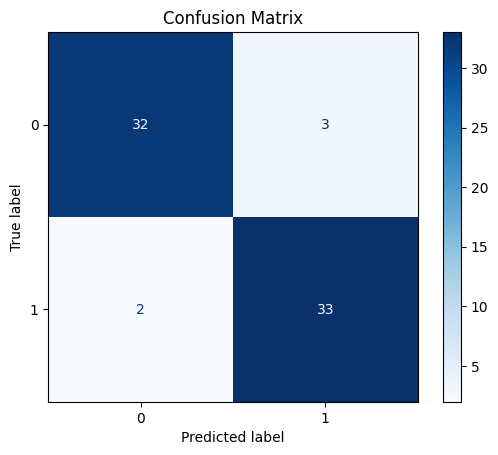

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical

#  [batch, time, channel]
x_test_transposed = np.transpose(X_val_norm, [0, 2, 1])  # shape: (samples, time, channels)


y_pred_prob = model.predict(x_test_transposed)


y_pred = np.argmax(y_pred_prob, axis=1)


if y_test.ndim > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_val, axis=1)
else:
    y_true = y_val

cm = confusion_matrix(y_true, y_pred)


disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.savefig(r'C:\Users\joji\Desktop\deepvocal_res.png')
plt.show()
